In [1]:
import os, math, random, gc, shutil, sys
import numpy as np
import pandas as pd
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from sklearn.metrics import (cohen_kappa_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)

In [2]:
DATASET_DIR  = '/kaggle/input/datasets/almiraraisa/aptos-2019-augmented'

device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_NAMES  = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']
NUM_CLASSES  = len(CLASS_NAMES)
BATCH_SIZE   = 32
NUM_EPOCHS   = 100
LR           = 1e-4
WEIGHT_DECAY = 1e-5
CKPT_DIR     = '/kaggle/working'
os.makedirs(CKPT_DIR, exist_ok=True)
print(f"Device: {device}")

Device: cuda


In [3]:
def set_seed(seed=30):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False

def cleanup_memory():
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

In [4]:
class AptosDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_col = 'id_code' if 'id_code' in self.df.columns else self.df.columns[0]
        fname = str(row[img_col]); fname = fname if fname.endswith('.png') else fname + '.png'
        img = Image.open(self.image_dir / fname).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, torch.tensor(int(row['diagnosis']), dtype=torch.long)

In [5]:
train_tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_df = pd.read_csv(f'{DATASET_DIR}/train_split.csv')
val_df   = pd.read_csv(f'{DATASET_DIR}/val_split.csv')
test_df  = pd.read_csv(f'{DATASET_DIR}/test_split.csv')

class_counts   = train_df['diagnosis'].value_counts().sort_index().values
sample_weights = train_df['diagnosis'].map(lambda x: 1.0 / class_counts[x]).values
sampler = WeightedRandomSampler(torch.tensor(sample_weights, dtype=torch.float),
                                len(sample_weights), replacement=True)
train_loader = DataLoader(AptosDataset(train_df, f'{DATASET_DIR}/images', train_tfm),
                          batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, pin_memory=True)
val_loader   = DataLoader(AptosDataset(val_df,   f'{DATASET_DIR}/images', val_tfm),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(AptosDataset(test_df,  f'{DATASET_DIR}/images', val_tfm),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

In [6]:
def preview_dataset(df, image_dir, split_name="Train"):
    image_dir = Path(image_dir)
    img_col   = 'id_code' if 'id_code' in df.columns else df.columns[0]
    fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(22, 4))
    fig.suptitle(f"Scenario 3 — Dataset Preview ({split_name})  |  1 random sample per class",
                 fontsize=13, fontweight='bold')
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        subset = df[df['diagnosis'] == cls_idx]
        row    = subset.sample(1, random_state=42).iloc[0]
        fname  = str(row[img_col]); fname = fname if fname.endswith('.png') else fname + '.png'
        img    = Image.open(image_dir / fname).convert('RGB')
        axes[cls_idx].imshow(img)
        axes[cls_idx].set_title(
            f"Class {cls_idx}: {cls_name}\nn={len(subset)} ({100*len(subset)/len(df):.1f}%)",
            fontsize=9)
        axes[cls_idx].axis('off')
    plt.tight_layout()
    plt.savefig(f'{CKPT_DIR}/dataset_preview.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("\n── Dataset Statistics ──────────────────────────────────")
    print(f"  Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    print("  Class distribution (train):")
    for i, name in enumerate(CLASS_NAMES):
        n = (train_df['diagnosis'] == i).sum()
        bar = '█' * int(30 * n / len(train_df))
        print(f"  [{i}] {name:<20s}: {n:4d} ({100*n/len(train_df):5.1f}%)  {bar}")

In [7]:
# coral helpers

class CoralLayer(nn.Module):
    def __init__(self, s, n):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(1, s))
        self.bias   = nn.Parameter(torch.zeros(n - 1))   # zeros is correct for CORAL bias
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
    def forward(self, x):
        return F.linear(x, self.weight) + self.bias


def label_to_levels(label, num_classes=5):
    """
    Convert integer class label to binary ordinal level vector.
    e.g. class 2  →  [1, 1, 0, 0]   (label > 0, label > 1, label > 2, label > 3)
    """
    levels = torch.zeros(label.size(0), num_classes - 1, device=label.device)
    for i in range(num_classes - 1):
        levels[:, i] = (label > i).float()
    return levels


class_weights_tensor = 1.0 / torch.tensor(class_counts, dtype=torch.float)
class_weights_tensor = class_weights_tensor / class_weights_tensor.mean()
class_weights_tensor = class_weights_tensor.to(device)


def weighted_coral_loss(logits, levels, labels):
    log_sigmoid = F.logsigmoid(logits)          # log σ(f_k),       shape (B, K-1)
    log_1m_sigm = log_sigmoid - logits          # log(1 − σ(f_k)),  shape (B, K-1)

    per_sample_loss = -torch.sum(
        log_sigmoid  * levels +
        log_1m_sigm  * (1.0 - levels),
        dim=1
    )                                           # shape: (B,)

    return (per_sample_loss * class_weights_tensor[labels]).mean()


def predict_coral(logits):
    return torch.sum(torch.sigmoid(logits) > 0.5, dim=1)


def ordinal_to_probs(logits, T=1.0):
    cumprobs = torch.sigmoid(logits / T)        # shape (B, K-1)
    ones  = torch.ones (logits.size(0), 1, device=logits.device)
    zeros = torch.zeros(logits.size(0), 1, device=logits.device)
    ext   = torch.cat([ones, cumprobs, zeros], dim=1)   # shape (B, K+1)
    return (ext[:, :-1] - ext[:, 1:]).clamp(min=1e-8)   # shape (B, K)

In [8]:
def compute_mse_rmse(labels, preds):
    """Compute MSE and RMSE treating DR grading as ordinal regression."""
    labels_arr = np.array(labels, dtype=np.float64)
    preds_arr  = np.array(preds,  dtype=np.float64)
    mse  = float(np.mean((labels_arr - preds_arr) ** 2))
    rmse = float(np.sqrt(mse))
    return mse, rmse

In [9]:
def analyse_results(results_list, scenario_title, loss_label="Loss", teacher_accs=None):
        # ── Unpack ────────────────────────────────────────────────────────────────
    seeds      = [r['seed'] for r in results_list]
    all_losses = np.array([r['history']['train_loss'] for r in results_list])
    all_qwks   = np.array([r['history']['val_qwk']    for r in results_list])
    all_accs   = np.array([r['history']['val_acc']    for r in results_list])
    all_mses   = np.array([r['history']['val_mse']    for r in results_list])
    all_rmses  = np.array([r['history']['val_rmse']   for r in results_list])
    epochs     = np.arange(1, all_losses.shape[1] + 1)
    best_res   = max(results_list, key=lambda x: x['qwk'])
    colors     = plt.cm.tab10.colors

    # Aggregate CMs across all seeds
    cms = [confusion_matrix(r['labels'], r['preds'], labels=list(range(NUM_CLASSES)))
           for r in results_list]
    cm_avg      = np.mean(cms, axis=0)
    cm_std      = np.std(cms,  axis=0)
    cm_avg_norm = cm_avg / cm_avg.sum(axis=1, keepdims=True)
    cm_best     = confusion_matrix(best_res['labels'], best_res['preds'],
                                   labels=list(range(NUM_CLASSES)))

    # Aggregate scalars
    seed_accs  = [np.mean(np.array(r['labels']) == np.array(r['preds'])) * 100 for r in results_list]
    seed_qwks  = [r['qwk']  for r in results_list]
    seed_mses  = [r['mse']  for r in results_list]
    seed_rmses = [r['rmse'] for r in results_list]
    mean_acc  = np.mean(seed_accs);  std_acc  = np.std(seed_accs)
    mean_qwk  = np.mean(seed_qwks);  std_qwk  = np.std(seed_qwks)
    mean_mse  = np.mean(seed_mses);  std_mse  = np.std(seed_mses)
    mean_rmse = np.mean(seed_rmses); std_rmse = np.std(seed_rmses)

    per_cls_acc = cm_avg.diagonal() / cm_avg.sum(axis=1)

    misclass = []
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            if i != j and cm_avg[i, j] > 0:
                misclass.append((cm_avg[i, j], i, j))
    misclass.sort(reverse=True)

    report   = classification_report(best_res['labels'], best_res['preds'],
                                     target_names=CLASS_NAMES, output_dict=True)
    best_acc = np.mean(np.array(best_res['labels']) == np.array(best_res['preds'])) * 100

    CKPT_SAFE = scenario_title.replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '')

    # =========================================================================
    # FIGURE 1 — Overview Dashboard  (3 rows × 4 cols)
    # =========================================================================
    fig1 = plt.figure(figsize=(24, 18))
    fig1.suptitle(f"{scenario_title}\n— Training Analysis Dashboard —",
                  fontsize=16, fontweight='bold', y=0.99)
    gs1 = gridspec.GridSpec(3, 4, figure=fig1, hspace=0.45, wspace=0.30)

    # ── R0C0: Val Accuracy Boxplot ────────────────────────────────────────────
    ax = fig1.add_subplot(gs1[0, 0])
    bp = ax.boxplot([seed_accs], patch_artist=True, widths=0.4,
                    medianprops=dict(color='red', lw=2))
    bp['boxes'][0].set_facecolor('#aec6e8')
    ax.scatter([1] * len(seed_accs), seed_accs, color='black', s=40, zorder=5)
    ax.set_xticks([1]); ax.set_xticklabels(['Student'])
    ax.set_title(f"Val Accuracy Distribution\n({len(seeds)} Seeds)", fontsize=11, fontweight='bold')
    ax.set_ylabel("Accuracy (%)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    ax.grid(True, axis='y', ls='--', alpha=0.5)
    ax.text(1, mean_acc, f"μ={mean_acc:.2f}%\nσ={std_acc:.2f}%",
            ha='center', va='bottom', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))

    # ── R0C1: Teacher vs Student bar / QWK distribution ──────────────────────
    ax = fig1.add_subplot(gs1[0, 1])
    if teacher_accs:
        names  = [f"Teacher {i+1}" for i in range(len(teacher_accs))] + ['Student']
        values = list(teacher_accs) + [mean_acc]
        bar_colors = ['#4878CF'] * len(teacher_accs) + ['#F8A60B']
        bars = ax.bar(range(len(names)), values, color=bar_colors, width=0.5,
                      edgecolor='white', lw=1.5)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f"{val:.2f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
        ax.set_ylim(min(values) - 5, 100)
        ax.set_title("Teacher vs Student Accuracy", fontsize=11, fontweight='bold')
        ax.set_ylabel("Accuracy (%)")
    else:
        bp2 = ax.boxplot([seed_qwks], patch_artist=True, widths=0.4,
                         medianprops=dict(color='red', lw=2))
        bp2['boxes'][0].set_facecolor('#b8d4a8')
        ax.scatter([1] * len(seed_qwks), seed_qwks, color='black', s=40, zorder=5)
        ax.set_xticks([1]); ax.set_xticklabels(['Student'])
        ax.set_title(f"Val QWK Distribution\n({len(seeds)} Seeds)", fontsize=11, fontweight='bold')
        ax.set_ylabel("Quadratic Weighted Kappa")
        ax.text(1, mean_qwk, f"μ={mean_qwk:.4f}\nσ={std_qwk:.4f}",
                ha='center', va='bottom', fontsize=8.5,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))
    ax.grid(True, axis='y', ls='--', alpha=0.5)

    # ── R0C2: Val Accuracy curves (mean ± std band) ───────────────────────────
    ax = fig1.add_subplot(gs1[0, 2])
    mean_a = all_accs.mean(0) * 100; std_a = all_accs.std(0) * 100
    ax.plot(epochs, mean_a, color='#1f77b4', lw=2.2, label='Mean')
    ax.fill_between(epochs, mean_a - std_a, mean_a + std_a,
                    alpha=0.25, color='#1f77b4', label='±1 std')
    ax.set_title("Validation Accuracy Curves", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy (%)")
    ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    # ── R0C3: Training Loss ───────────────────────────────────────────────────
    ax = fig1.add_subplot(gs1[0, 3])
    mean_l = all_losses.mean(0); std_l = all_losses.std(0)
    ax.plot(epochs, mean_l, color='blue', lw=2.0, label=loss_label)
    ax.fill_between(epochs, mean_l - std_l, mean_l + std_l, alpha=0.15, color='blue')
    ax.set_title("Training Loss (Averaged)", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss Value (Normalized)")
    ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    # ── R1C0: Individual run validation curves ────────────────────────────────
    ax = fig1.add_subplot(gs1[1, 0])
    for i, r in enumerate(results_list):
        ax.plot(epochs, [a*100 for a in r['history']['val_acc']],
                color=colors[i], lw=1.5, alpha=0.8, label=f"Run {i+1}")
    ax.plot(epochs, mean_a, 'k--', lw=2.2, label='Average')
    ax.set_title("Individual Run Validation Curves", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
    ax.legend(fontsize=8); ax.grid(True, ls='--', alpha=0.5)

    # ── R1C1: MSE curves (mean ± std band) ───────────────────────────────────
    ax = fig1.add_subplot(gs1[1, 1])
    mean_mse_curve = all_mses.mean(0);  std_mse_curve  = all_mses.std(0)
    mean_rmse_curve= all_rmses.mean(0); std_rmse_curve = all_rmses.std(0)
    ax.plot(epochs, mean_mse_curve,  color='darkorange',  lw=2.0, label='MSE (mean)')
    ax.fill_between(epochs, mean_mse_curve - std_mse_curve,
                    mean_mse_curve + std_mse_curve, alpha=0.2, color='darkorange')
    ax.plot(epochs, mean_rmse_curve, color='crimson', lw=2.0, ls='--', label='RMSE (mean)')
    ax.fill_between(epochs, mean_rmse_curve - std_rmse_curve,
                    mean_rmse_curve + std_rmse_curve, alpha=0.15, color='crimson')
    ax.set_title("Val MSE & RMSE Over Training", fontsize=11, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Error (ordinal scale)")
    ax.legend(fontsize=9); ax.grid(True, ls='--', alpha=0.5)

    # ── R1C2: Average CM raw counts ───────────────────────────────────────────
    ax = fig1.add_subplot(gs1[1, 2])
    im = ax.imshow(cm_avg, cmap='Blues', interpolation='nearest')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Average Confusion Matrix\n(Raw Counts)", fontsize=11, fontweight='bold')
    thresh = cm_avg.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_avg[i,j]:.0f}", ha='center', va='center', fontsize=8,
                    color='white' if cm_avg[i,j] > thresh else 'black')

    # ── R1C3: Average CM normalized ───────────────────────────────────────────
    ax = fig1.add_subplot(gs1[1, 3])
    im2 = ax.imshow(cm_avg_norm, cmap='Blues', interpolation='nearest', vmin=0, vmax=1)
    plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Average Confusion Matrix\n(Normalized)", fontsize=11, fontweight='bold')
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_avg_norm[i,j]:.3f}", ha='center', va='center', fontsize=7.5,
                    color='white' if cm_avg_norm[i,j] > 0.5 else 'black')

    # ── R2C0: Per-class accuracy bar ──────────────────────────────────────────
    ax = fig1.add_subplot(gs1[2, 0])
    bar_colors_cls = ['#d4edda' if a >= 0.7 else ('#fff3cd' if a >= 0.5 else '#f8d7da')
                      for a in per_cls_acc]
    bars = ax.bar(range(NUM_CLASSES), per_cls_acc * 100, color=bar_colors_cls,
                  edgecolor='grey', lw=0.8)
    for bar, val in zip(bars, per_cls_acc):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val*100:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title("Per-Class Accuracy\n(from Averaged CM)", fontsize=11, fontweight='bold')
    ax.set_ylabel("Accuracy (%)"); ax.set_ylim(0, 115)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8)
    ax.grid(True, axis='y', ls='--', alpha=0.5)

    # ── R2C1: CM standard deviation heatmap ───────────────────────────────────
    ax = fig1.add_subplot(gs1[2, 1])
    im3 = ax.imshow(cm_std, cmap='Oranges', interpolation='nearest')
    plt.colorbar(im3, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix\nStandard Deviation", fontsize=11, fontweight='bold')
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_std[i,j]:.2f}", ha='center', va='center',
                    fontsize=7.5, color='black')

    # ── R2C2: Best-run CM ─────────────────────────────────────────────────────
    ax = fig1.add_subplot(gs1[2, 2])
    im4 = ax.imshow(cm_best, cmap='Greens', interpolation='nearest')
    plt.colorbar(im4, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=7.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title(f"Best Run CM (Seed {best_res['seed']}: {best_acc:.2f}%)",
                 fontsize=11, fontweight='bold')
    thresh2 = cm_best.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_best[i,j]}", ha='center', va='center', fontsize=8,
                    color='white' if cm_best[i,j] > thresh2 else 'black')

    # ── R2C3: Per-class F1 bar ────────────────────────────────────────────────
    ax = fig1.add_subplot(gs1[2, 3])
    f1_scores = [report[cls]['f1-score'] for cls in CLASS_NAMES]
    f1_colors = ['#d4edda' if f >= 0.7 else ('#fff3cd' if f >= 0.5 else '#f8d7da')
                 for f in f1_scores]
    f1_bars = ax.bar(range(NUM_CLASSES), [f*100 for f in f1_scores],
                     color=f1_colors, edgecolor='grey', lw=0.8)
    for bar, val in zip(f1_bars, f1_scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val*100:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title("Per-Class F1 Score\n(Best Seed)", fontsize=11, fontweight='bold')
    ax.set_ylabel("F1 Score (%)"); ax.set_ylim(0, 115)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8)
    ax.axhline(70, color='green', ls=':', lw=1.2, alpha=0.6)
    ax.grid(True, axis='y', ls='--', alpha=0.5)

    fig1.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(f'{CKPT_DIR}/{CKPT_SAFE}_dashboard.png', dpi=130, bbox_inches='tight')
    plt.show()

    # =========================================================================
    # FIGURE 2 — Detailed CM Analysis + Performance Summary
    # =========================================================================
    fig2 = plt.figure(figsize=(20, 20))
    fig2.suptitle(f"{scenario_title}\n— Detailed Confusion Matrix Analysis —",
                  fontsize=15, fontweight='bold', y=0.99)
    gs2 = gridspec.GridSpec(3, 2, figure=fig2, hspace=0.38, wspace=0.28,
                            height_ratios=[1, 1, 0.52])

    # ── Avg CM raw ────────────────────────────────────────────────────────────
    ax = fig2.add_subplot(gs2[0, 0])
    im = ax.imshow(cm_avg, cmap='Blues', interpolation='nearest')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Average Confusion Matrix (Raw Counts)", fontsize=12, fontweight='bold')
    thresh = cm_avg.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_avg[i,j]:.0f}", ha='center', va='center', fontsize=9,
                    color='white' if cm_avg[i,j] > thresh else 'black')

    # ── Avg CM normalized ─────────────────────────────────────────────────────
    ax = fig2.add_subplot(gs2[0, 1])
    im2 = ax.imshow(cm_avg_norm, cmap='Blues', interpolation='nearest', vmin=0, vmax=1)
    plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Average Confusion Matrix (Normalized)", fontsize=12, fontweight='bold')
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_avg_norm[i,j]:.3f}", ha='center', va='center', fontsize=8.5,
                    color='white' if cm_avg_norm[i,j] > 0.5 else 'black')

    # ── CM std deviation ──────────────────────────────────────────────────────
    ax = fig2.add_subplot(gs2[1, 0])
    im3 = ax.imshow(cm_std, cmap='Oranges', interpolation='nearest')
    plt.colorbar(im3, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix Standard Deviation", fontsize=12, fontweight='bold')
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_std[i,j]:.2f}", ha='center', va='center',
                    fontsize=8.5, color='black')

    # ── Best-run CM ───────────────────────────────────────────────────────────
    ax = fig2.add_subplot(gs2[1, 1])
    im4 = ax.imshow(cm_best, cmap='Greens', interpolation='nearest')
    plt.colorbar(im4, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=8.5)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8.5)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title(f"Best Run CM (Seed {best_res['seed']}: {best_acc:.2f}%)",
                 fontsize=12, fontweight='bold')
    thresh2 = cm_best.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_best[i,j]}", ha='center', va='center', fontsize=9,
                    color='white' if cm_best[i,j] > thresh2 else 'black')

    # ── Performance Summary Text Panel ────────────────────────────────────────
    ax_txt = fig2.add_subplot(gs2[2, :])
    ax_txt.axis('off')

    lines = []
    lines.append("=" * 84)
    lines.append(f"  PERFORMANCE SUMMARY — {scenario_title}")
    lines.append("=" * 84)
    lines.append(f"  Seeds trained              : {seeds}")
    lines.append(f"  Val Accuracy  (mean ± std) : {mean_acc:.2f}%  ±  {std_acc:.2f}%"
                 f"  [range: {min(seed_accs):.2f}% – {max(seed_accs):.2f}%]")
    lines.append(f"  Val QWK       (mean ± std) : {mean_qwk:.4f}  ±  {std_qwk:.4f}"
                 f"  [range: {min(seed_qwks):.4f} – {max(seed_qwks):.4f}]")
    lines.append(f"  Val MSE       (mean ± std) : {mean_mse:.4f}  ±  {std_mse:.4f}"
                 f"  [range: {min(seed_mses):.4f} – {max(seed_mses):.4f}]")
    lines.append(f"  Val RMSE      (mean ± std) : {mean_rmse:.4f}  ±  {std_rmse:.4f}"
                 f"  [range: {min(seed_rmses):.4f} – {max(seed_rmses):.4f}]")
    lines.append(f"  Best seed                  : Seed {best_res['seed']}"
                 f"  (QWK={best_res['qwk']:.4f}, Acc={best_acc:.2f}%,"
                 f" MSE={best_res['mse']:.4f}, RMSE={best_res['rmse']:.4f})")
    lines.append(f"  Final train loss (mean)    : {all_losses[:, -1].mean():.4f}"
                 f"  ±  {all_losses[:, -1].std():.4f}")
    lines.append(f"  Peak QWK epoch  (mean)     : "
                 f"{np.mean([np.argmax(r['history']['val_qwk'])+1 for r in results_list]):.1f}")
    lines.append("")
    lines.append("  Per-class Performance (best seed):")
    lines.append(f"  {'Class':<20s}  {'Precision':>9s}  {'Recall':>9s}  "
                 f"{'F1-Score':>9s}  {'Support':>7s}  {'Status'}")
    lines.append("  " + "-" * 72)
    for cls in CLASS_NAMES:
        d    = report[cls]
        flag = '✓ Good' if d['f1-score'] >= 0.7 else ('~ OK' if d['f1-score'] >= 0.5 else '✗ Poor')
        lines.append(f"  {cls:<20s}  {d['precision']:>9.3f}  {d['recall']:>9.3f}  "
                     f"{d['f1-score']:>9.3f}  {int(d['support']):>7d}  {flag}")
    lines.append("  " + "-" * 72)
    lines.append(f"  {'Overall Accuracy':<20s}  {'—':>9s}  {'—':>9s}  "
                 f"{report['accuracy']:>9.3f}  {len(best_res['labels']):>7d}")
    lines.append(f"  {'Macro Avg F1':<20s}  {report['macro avg']['precision']:>9.3f}  "
                 f"{report['macro avg']['recall']:>9.3f}  "
                 f"{report['macro avg']['f1-score']:>9.3f}  {'—':>7s}")
    lines.append(f"  {'Weighted Avg F1':<20s}  {report['weighted avg']['precision']:>9.3f}  "
                 f"{report['weighted avg']['recall']:>9.3f}  "
                 f"{report['weighted avg']['f1-score']:>9.3f}  {'—':>7s}")
    lines.append("")
    lines.append("  Top-5 Most Common Misclassifications (averaged across seeds):")
    for rank, (count, true_c, pred_c) in enumerate(misclass[:5], 1):
        pct = count / cm_avg.sum(axis=1)[true_c] * 100
        lines.append(f"    {rank}. True={CLASS_NAMES[true_c]:<20s} → "
                     f"Predicted={CLASS_NAMES[pred_c]:<20s}"
                     f"  (avg count={count:.1f}, {pct:.1f}% of true class)")
    lines.append("")
    lines.append("  Class Performance Range (per-class accuracy from averaged CM):")
    cls_accs_sorted = sorted(zip(per_cls_acc, CLASS_NAMES), reverse=True)
    lines.append(f"    Best  : {cls_accs_sorted[0][1]}  ({cls_accs_sorted[0][0]*100:.1f}%)")
    lines.append(f"    Worst : {cls_accs_sorted[-1][1]}  ({cls_accs_sorted[-1][0]*100:.1f}%)")
    lines.append(f"    Gap   : {(cls_accs_sorted[0][0]-cls_accs_sorted[-1][0])*100:.1f}pp")
    lines.append("=" * 84)

    summary_text = '\n'.join(lines)
    ax_txt.text(0.01, 0.99, summary_text, transform=ax_txt.transAxes,
                fontsize=7.8, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='#f8f9fa', alpha=0.9, edgecolor='#dee2e6'))

    fig2.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(f'{CKPT_DIR}/{CKPT_SAFE}_cm_detail.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('\n'.join(lines))

In [10]:
TEMPERATURE = 5.0
ALPHA       = 0.7

def get_effb3_teacher():
    m = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
    m.classifier[-1] = CoralLayer(m.classifier[-1].in_features, NUM_CLASSES)
    return m

def get_mobilenet_student():
    m = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    m.classifier[-1] = CoralLayer(m.classifier[-1].in_features, NUM_CLASSES)
    return m

def train_teacher_coral(model, seed):
    name      = f"EfficientNet-B3_Seed{seed}"
    save_path = f'{CKPT_DIR}/s3_teacher_effb3_coral_seed{seed}.pth'

    model  = model.to(device)
    opt    = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS)
    scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else torch.amp.GradScaler('cpu')

    best_qwk = -1.0
    best_acc =  0.0
    history  = {'train_loss': [], 'val_qwk': [], 'val_acc': [], 'val_mse': [], 'val_rmse': []}

    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            opt.zero_grad()
            with torch.amp.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu'):
                loss = weighted_coral_loss(model(imgs), label_to_levels(labels), labels)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        sched.step()

        model.eval()
        v_preds, v_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                v_preds.extend(predict_coral(model(imgs.to(device))).cpu().numpy())
                v_labels.extend(labels.numpy())

        qwk  = float(cohen_kappa_score(v_labels, v_preds, weights='quadratic'))
        acc  = float(np.mean(np.array(v_labels) == np.array(v_preds)))
        mse, rmse = compute_mse_rmse(v_labels, v_preds)
        history['val_qwk'].append(qwk)
        history['val_acc'].append(acc)
        history['val_mse'].append(mse)
        history['val_rmse'].append(rmse)

        print(f"  [{name}] Epoch {epoch+1:03d} | Loss: {avg_loss:.4f} | "
              f"Acc: {acc*100:.2f}% | QWK: {qwk:.4f} | MSE: {mse:.4f} | RMSE: {rmse:.4f}")
        sys.stdout.flush()

        if qwk > best_qwk:
            best_qwk = qwk; best_acc = acc
            torch.save({'epoch': epoch+1, 'model_state_dict': model.state_dict(),
                        'qwk': best_qwk, 'history': history}, save_path)

    model.load_state_dict(torch.load(save_path, map_location=device,
                                     weights_only=False)['model_state_dict'])
    model.eval()
    print(f"\n  ✓ [{name}] Training complete — best val QWK: {best_qwk:.4f}")
    return model, best_acc

In [11]:
def train_student_s3(student, teacher_model, seed, alpha=ALPHA, temperature=TEMPERATURE):
    save_path = f'{CKPT_DIR}/s3_seed{seed}_best.pth'
    student   = student.to(device)

    teacher_ref = teacher_model.to(device).eval()
    for p in teacher_ref.parameters(): p.requires_grad_(False)

    opt    = optim.AdamW(student.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS)
    scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else torch.amp.GradScaler('cpu')

    best_qwk = -1.0
    history  = {'train_loss': [], 'val_qwk': [], 'val_acc': [], 'val_mse': [], 'val_rmse': []}
    best_preds, best_labels = [], []

    for epoch in range(NUM_EPOCHS):
        student.train(); running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            opt.zero_grad()
            with torch.amp.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu'):
                s_l  = student(imgs)
                t_l  = teacher_ref(imgs)
                lvls = label_to_levels(labels)

                # Hard ordinal loss (weighted by class frequency)
                hard = weighted_coral_loss(s_l, lvls, labels)

                # Soft ordinal KD loss
                # FIX 2 ── temperature divides logits inside ordinal_to_probs (already done).
                # FIX 3 ── multiply KL by T, NOT T².
                #           T² is a softmax-KD identity that does not apply to
                #           ordinal sigmoid probabilities; using it with T=5
                #           makes the KL term 25× too large and kills training.
                s_p  = ordinal_to_probs(s_l, temperature)
                t_p  = ordinal_to_probs(t_l.detach(), temperature)
                kl   = F.kl_div(s_p.log(), t_p, reduction='batchmean') * temperature  # ← was * T**2

                loss = (1 - alpha) * hard + alpha * kl

            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        sched.step()

        student.eval(); v_preds, v_labels = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                v_preds.extend(predict_coral(student(imgs.to(device))).cpu().numpy())
                v_labels.extend(labels.numpy())

        qwk  = float(cohen_kappa_score(v_labels, v_preds, weights='quadratic'))
        acc  = float(np.mean(np.array(v_labels) == np.array(v_preds)))
        mse, rmse = compute_mse_rmse(v_labels, v_preds)
        history['val_qwk'].append(qwk)
        history['val_acc'].append(acc)
        history['val_mse'].append(mse)
        history['val_rmse'].append(rmse)

        print(f"  [Student] Epoch {epoch+1:03d} | Loss: {avg_loss:.4f} | "
              f"Acc: {acc*100:.2f}% | QWK: {qwk:.4f} | MSE: {mse:.4f} | RMSE: {rmse:.4f}")
        sys.stdout.flush()

        if qwk > best_qwk:
            best_qwk = qwk; best_preds, best_labels = list(v_preds), list(v_labels)
            torch.save({'epoch': epoch+1, 'model_state_dict': student.state_dict(),
                        'qwk': best_qwk, 'history': history}, save_path)

    best_mse, best_rmse = compute_mse_rmse(best_labels, best_preds)
    print(f"\n  ✓ Saved → {save_path}  (best QWK={best_qwk:.4f},"
          f" MSE={best_mse:.4f}, RMSE={best_rmse:.4f})")
    return {'qwk': best_qwk, 'mse': best_mse, 'rmse': best_rmse,
            'history': history, 'preds': best_preds, 'labels': best_labels, 'seed': seed}

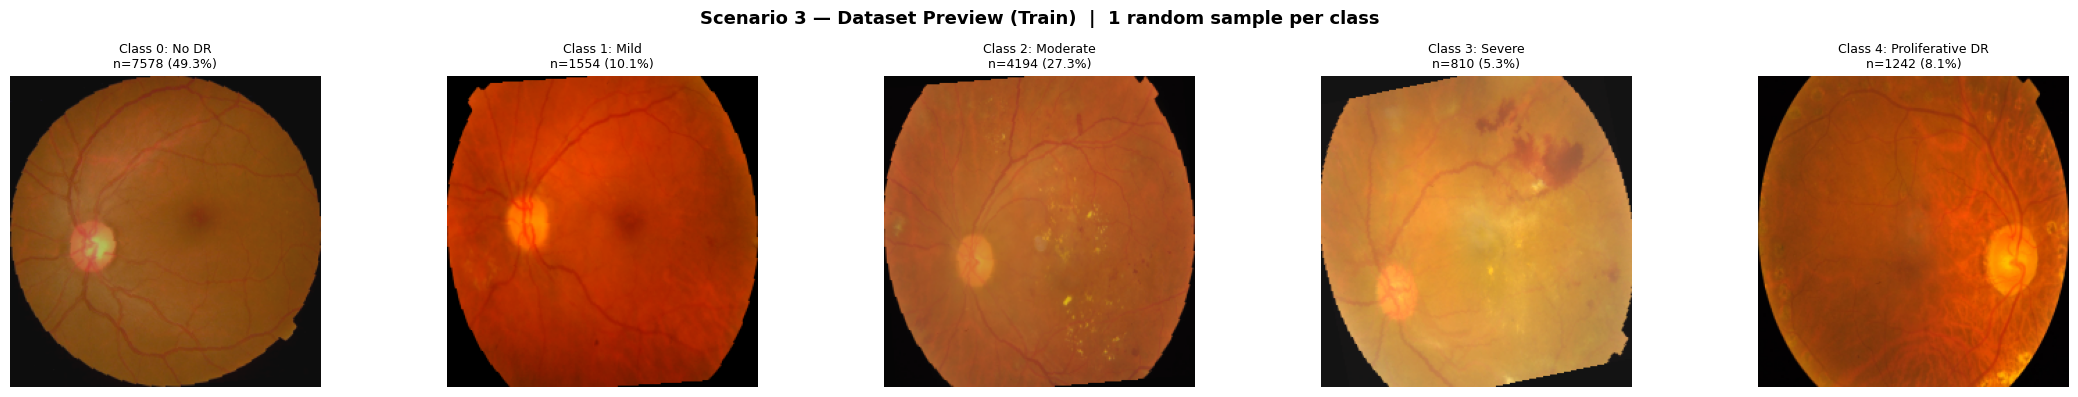


── Dataset Statistics ──────────────────────────────────
  Train: 15378 | Val: 549 | Test: 550
  Class distribution (train):
  [0] No DR               : 7578 ( 49.3%)  ██████████████
  [1] Mild                : 1554 ( 10.1%)  ███
  [2] Moderate            : 4194 ( 27.3%)  ████████
  [3] Severe              :  810 (  5.3%)  █
  [4] Proliferative DR    : 1242 (  8.1%)  ██

  SCENARIO 3 — Ordinal KD (EffB3 CORAL)  |  Seed 33
--- Training Teacher for Seed 33 ---
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 76.4MB/s]


  [EfficientNet-B3_Seed33] Epoch 001 | Loss: 1.9520 | Acc: 56.47% | QWK: 0.6892 | MSE: 1.5501 | RMSE: 1.2450
  [EfficientNet-B3_Seed33] Epoch 002 | Loss: 1.6977 | Acc: 57.01% | QWK: 0.7028 | MSE: 1.4335 | RMSE: 1.1973
  [EfficientNet-B3_Seed33] Epoch 003 | Loss: 1.5783 | Acc: 56.65% | QWK: 0.6920 | MSE: 1.4372 | RMSE: 1.1988
  [EfficientNet-B3_Seed33] Epoch 004 | Loss: 1.5532 | Acc: 57.19% | QWK: 0.7069 | MSE: 1.3297 | RMSE: 1.1531
  [EfficientNet-B3_Seed33] Epoch 005 | Loss: 1.4808 | Acc: 56.47% | QWK: 0.6880 | MSE: 1.3625 | RMSE: 1.1673
  [EfficientNet-B3_Seed33] Epoch 006 | Loss: 1.4618 | Acc: 57.19% | QWK: 0.7033 | MSE: 1.2987 | RMSE: 1.1396
  [EfficientNet-B3_Seed33] Epoch 007 | Loss: 1.4383 | Acc: 58.29% | QWK: 0.7138 | MSE: 1.2240 | RMSE: 1.1064
  [EfficientNet-B3_Seed33] Epoch 008 | Loss: 1.3931 | Acc: 59.20% | QWK: 0.7197 | MSE: 1.1585 | RMSE: 1.0763
  [EfficientNet-B3_Seed33] Epoch 009 | Loss: 1.3520 | Acc: 59.56% | QWK: 0.7498 | MSE: 1.0747 | RMSE: 1.0367
  [EfficientNet-B3_

100%|██████████| 9.83M/9.83M [00:00<00:00, 102MB/s]


  [Student] Epoch 001 | Loss: 4.6848 | Acc: 55.74% | QWK: 0.6396 | MSE: 1.6922 | RMSE: 1.3008
  [Student] Epoch 002 | Loss: 4.1050 | Acc: 55.56% | QWK: 0.6510 | MSE: 1.6794 | RMSE: 1.2959
  [Student] Epoch 003 | Loss: 3.8203 | Acc: 54.83% | QWK: 0.6299 | MSE: 1.6648 | RMSE: 1.2903
  [Student] Epoch 004 | Loss: 3.6954 | Acc: 55.56% | QWK: 0.6427 | MSE: 1.6157 | RMSE: 1.2711
  [Student] Epoch 005 | Loss: 3.6154 | Acc: 56.28% | QWK: 0.6767 | MSE: 1.5373 | RMSE: 1.2399
  [Student] Epoch 006 | Loss: 3.5194 | Acc: 56.10% | QWK: 0.6699 | MSE: 1.5355 | RMSE: 1.2392
  [Student] Epoch 007 | Loss: 3.4498 | Acc: 55.56% | QWK: 0.6430 | MSE: 1.6120 | RMSE: 1.2697
  [Student] Epoch 008 | Loss: 3.4153 | Acc: 56.28% | QWK: 0.6660 | MSE: 1.5264 | RMSE: 1.2355
  [Student] Epoch 009 | Loss: 3.3249 | Acc: 57.19% | QWK: 0.6846 | MSE: 1.4699 | RMSE: 1.2124
  [Student] Epoch 010 | Loss: 3.2809 | Acc: 55.19% | QWK: 0.6431 | MSE: 1.5811 | RMSE: 1.2574
  [Student] Epoch 011 | Loss: 3.2305 | Acc: 56.28% | QWK: 0.

In [ ]:
preview_dataset(train_df, f'{DATASET_DIR}/images')

results_s3         = []
teacher_accuracies = []

for seed in [33, 81, 5]:
    set_seed(seed)
    print(f"\n{'='*60}\n  SCENARIO 3 — Ordinal KD (EffB3 CORAL)  |  Seed {seed}\n{'='*60}")

    print(f"--- Training Teacher for Seed {seed} ---")
    current_teacher, t_acc = train_teacher_coral(get_effb3_teacher(), seed)
    teacher_accuracies.append(t_acc * 100)

    print(f"\n--- Training Student for Seed {seed} ---")
    res = train_student_s3(get_mobilenet_student(), current_teacher, seed)
    results_s3.append(res)

    cleanup_memory()

In [ ]:
analyse_results(results_s3,
                "Scenario 3 Single-Teacher Ordinal KD (EffB3 CORAL to MobileNetV3)",
                loss_label="KD Loss (CORAL + KL-Ordinal)",
                teacher_accs=teacher_accuracies)